<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista6-MateuszOlech/blob/main/Lista6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lista 6

In [25]:
# IMPORTY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

## Zadanie 1.1: Pobranie Danych i EDA
- Pobierz zbiór danych Speed Dating korzystając z sklearn.datasets.fetch_openml (id=40536).
- Wykonaj analizę danych i wygeneruj wizualizacje. Zwróć szczególną uwagę na rozkład zmiennych i zależności między nimi.

In [26]:
speed_dating = fetch_openml(data_id=40536, as_frame=True, parser='auto')
df = speed_dating.data
df['match'] = speed_dating.target
df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1
4,0,1,female,21.0,24.0,3,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,4.0,[0-4],[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1


In [27]:
# INFO
print(f"Rozmiar: {df.shape[0]} wierszy, {df.shape[1]} kolumn.\n{20*'-'}")
print(f"Kolumny: {list(df.columns)}\n{20*'-'}")
print(f"Typy danych:")
print(df.dtypes)


Rozmiar: 8378 wierszy, 121 kolumn.
--------------------
Kolumny: ['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o', 'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important', 'd_funny_important', 'd_ambtition_impor

Text(0, 0.5, 'Liczność klasy')

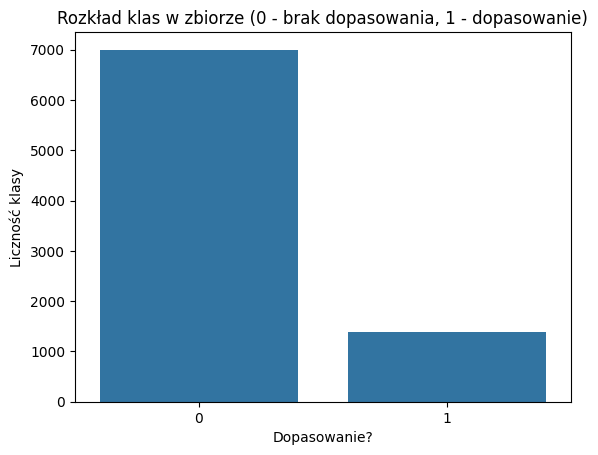

In [ ]:
sns.countplot(
    data=df,
    x='match'
)
plt.title("Rozkład klas w zbiorze (0 - brak dopasowania, 1 - dopasowanie)")
plt.xlabel("Dopasowanie?")
plt.ylabel("Liczność klasy")

In [22]:
# USUNIĘCIĘ WIEDZY "Z PRZYSZŁOŚCI"
columns_to_drop = [
    'decision', 'decision_o', 'met', 'guess_prob_liked', 'like', 'interests_correlate',
    'd_like', 'd_guess_prob_liked', 'd_interests_correlate',
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
    'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o',
    'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner',
    'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner', 'd_funny_partner', 'd_ambition_partner', 'd_shared_interests_partner',
    'has_null',
    'expected_happy_with_sd_people', 'expected_num_interested_in_me', 'expected_num_matches',
    'd_expected_happy_with_sd_people', 'd_expected_num_interested_in_me', 'd_expected_num_matches'
]

df = df.drop(columns=columns_to_drop, errors='ignore')
cols = [col for col in df.columns]
print(cols)

['wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important', 'd_funny_important', 'd_ambtition_important', 'd_shared_interests_important', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading',

In [ ]:
# MACIERZ KORELACJI


In [28]:
missing = df.isnull().sum()
df_missing = pd.DataFrame({'Liczba braków': missing, 'Rodzaj kolumny': df.dtypes})
df_missing = df_missing[df_missing['Liczba braków'] > 0]
print(f"Braki danych:")
print(df_missing)

Braki danych:
                               Liczba braków Rodzaj kolumny
age                                       95        float64
age_o                                    104        float64
race                                      63       category
race_o                                    73       category
importance_same_race                      79        float64
importance_same_religion                  79        float64
field                                     63       category
pref_o_attractive                         89        float64
pref_o_sincere                            89        float64
pref_o_intelligence                       89        float64
pref_o_funny                              98        float64
pref_o_ambitious                         107        float64
pref_o_shared_interests                  129        float64
attractive_o                             212        float64
sinsere_o                                287        float64
intelligence_o            